**About this Notebook**

v3 of this notebook aims to condense code and create functions to replace standardization, and imputation standardization and imputations steps. Other changes include:
- Move the section that converts boolean to integers after the dummy variables section
- created a standardizze() fxn to replace standardization function in v2
- created a impute_please() fxn to replace the imputation steps in v2
- goal of creating these fxns was to more easily easily apply the same standardization and imputation steps to different types of train/test splits to answer different questions
- save data from three types of train-test splits in different subfolders (random, group, temporal). Note saved data is not standardized or imputed since this will happen before modeling in the next script 0.4-gna-modeling_v2.ipynb

# 1. Import pkgs

In [353]:
import numpy as np 
import pandas as pd
import os
!pip install missingno
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [354]:
from sklearn.model_selection import GroupKFold

# 2. Load Data

In [355]:
!cd "/Users/grace/Documents/GitHubRepos/capstone2_immunization/"
data = pd.read_csv("/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/imm_df_cleaner_no_imput.csv")

In [356]:
print(f"Check county_name is in the data set? {'county_name' in (data.columns)}")

Check county_name is in the data set? True


In [357]:
print(data.shape)
data.columns

(1016, 38)


Index(['county_name', '% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)', 'SVI Category',
       'CVAC level of concern for vaccination rollout',
       'CVAC Level Of Concern', 'other_pc_provider_ratio_numerator',
       'pop_tertiles', 'seg_missing_bool'],
      dtype='object')

# Remove missing values
- not sure how to deal with missing values among features/covariates given i have time series data

<Axes: >

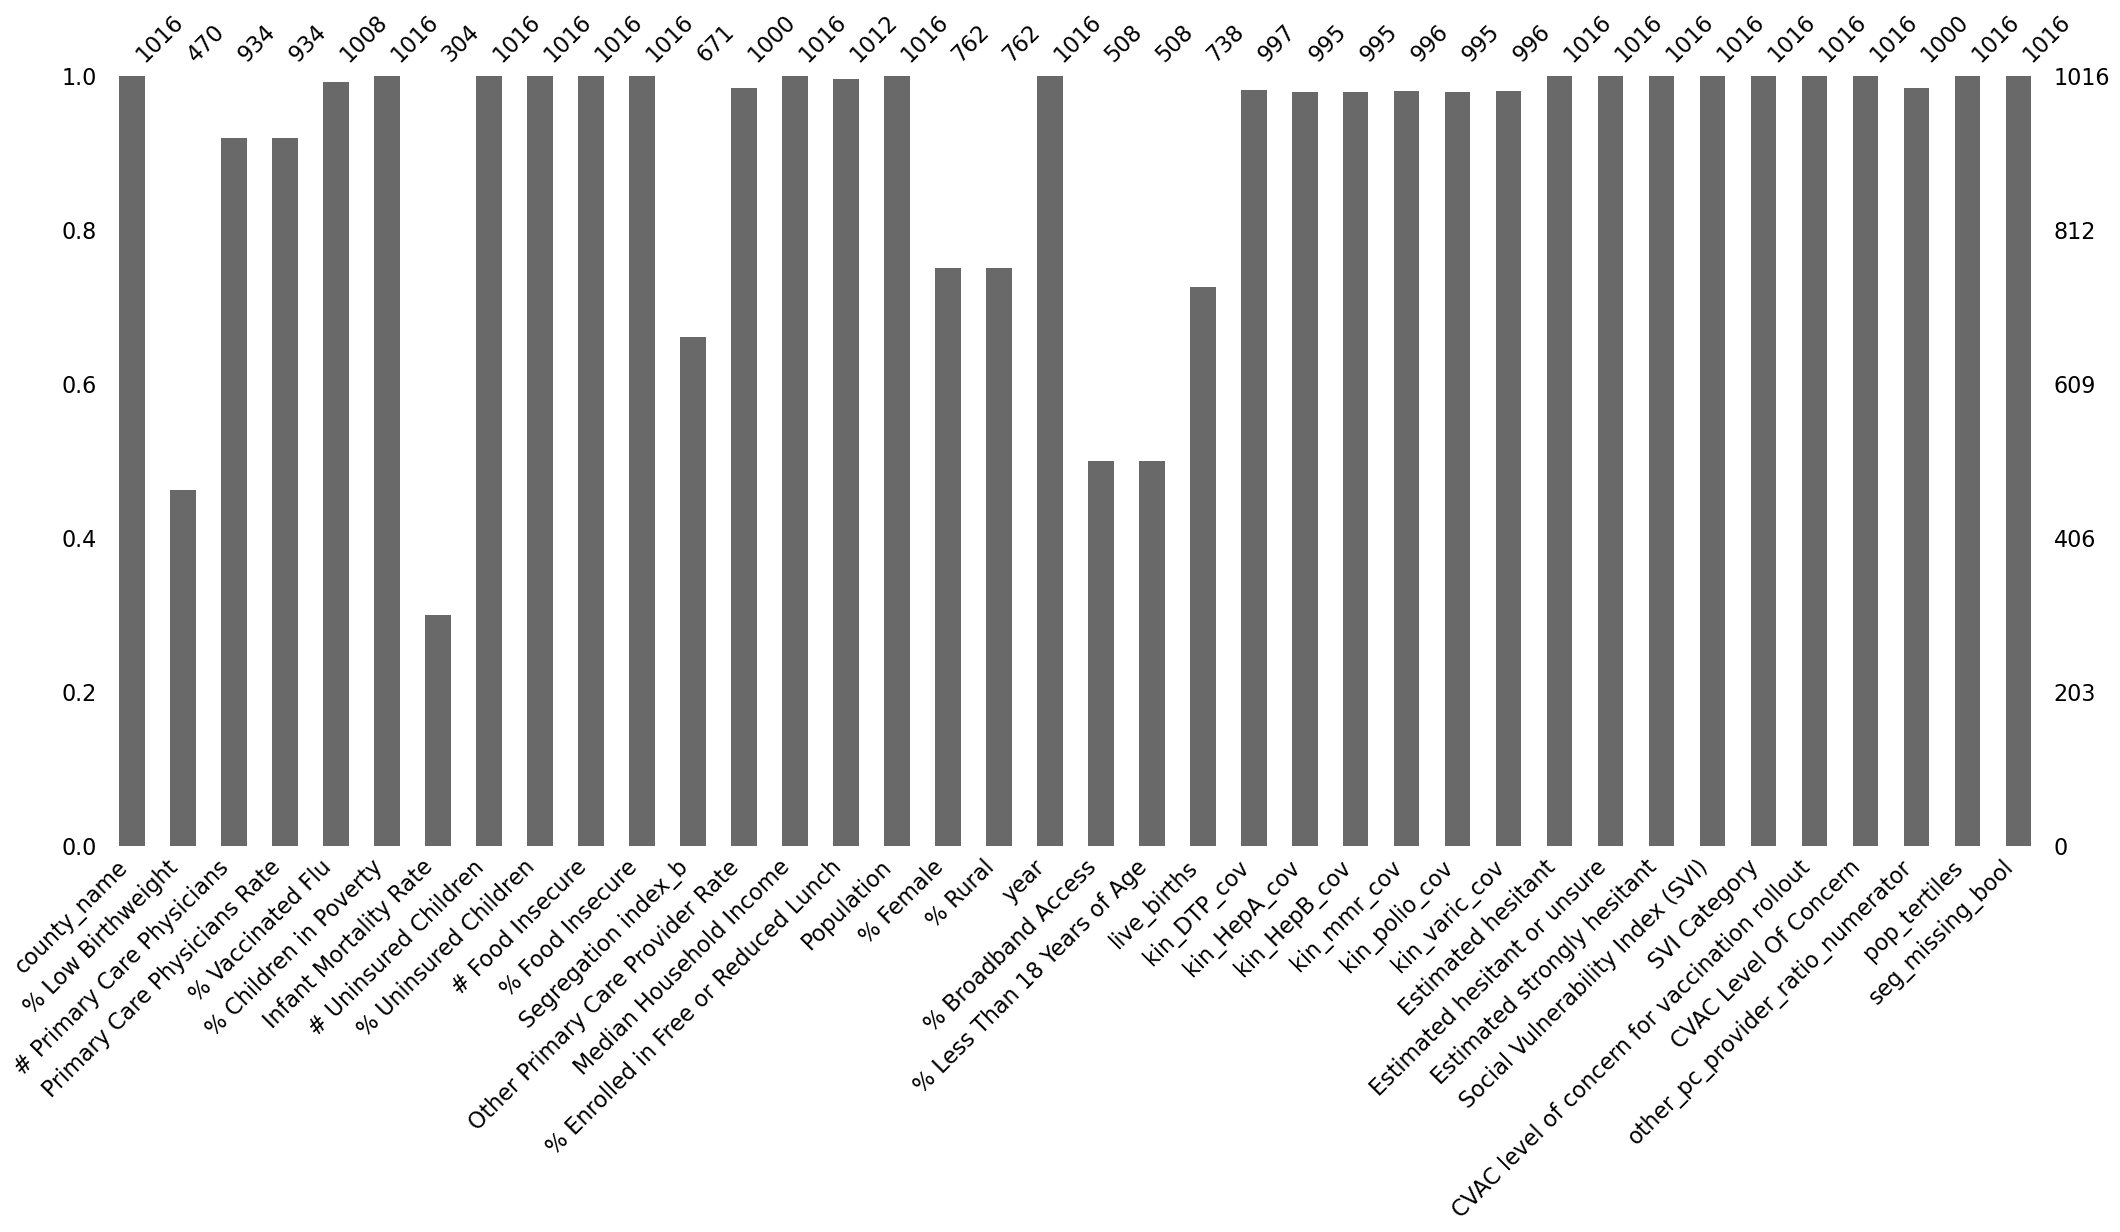

In [358]:
msno.bar(data)

In [359]:
missing_y_mask = data['kin_mmr_cov'].isna()
print(missing_y_mask.sum())
county_year_missing_kin_mmr_cov = data.loc[missing_y_mask,['county_name','year','kin_mmr_cov']].sort_values(by= ['county_name','kin_mmr_cov'])
print(county_year_missing_kin_mmr_cov)

20
    county_name  year  kin_mmr_cov
58       DeWitt  2020          NaN
312      DeWitt  2021          NaN
566      DeWitt  2022          NaN
820      DeWitt  2023          NaN
646    La Salle  2022          NaN
150      Loving  2020          NaN
404      Loving  2021          NaN
658      Loving  2022          NaN
912      Loving  2023          NaN
413   McCulloch  2021          NaN
667   McCulloch  2022          NaN
921   McCulloch  2023          NaN
414    McLennan  2021          NaN
668    McLennan  2022          NaN
922    McLennan  2023          NaN
161    McMullen  2020          NaN
415    McMullen  2021          NaN
669    McMullen  2022          NaN
923    McMullen  2023          NaN
216   Stonewall  2020          NaN


In [360]:
type(county_year_missing_kin_mmr_cov)
county_year_missing_kin_mmr_cov.shape

(20, 3)

There are 20 rows of data with y missing. Save them as a separate data frame missing_y_df.
Use a mask to delete them from the working data set.

In [361]:
missing_y_df = data.loc[missing_y_mask]
missing_y_idx = data.loc[missing_y_mask].index
data_test = data.loc[~data.index.isin(missing_y_idx)]
print("Shape before deleting rows with missing data:", data.shape)
print("Shape after deleting rows with missing data:", data_test.shape)


Shape before deleting rows with missing data: (1016, 38)
Shape after deleting rows with missing data: (996, 38)


In [362]:
# save most recent changes
data = data_test

In [363]:
data.select_dtypes(include = 'object').columns

Index(['county_name', 'SVI Category', 'CVAC Level Of Concern', 'pop_tertiles'], dtype='object')

In [364]:
data.dtypes

county_name                                       object
% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
Infant Mortality Rate                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Segregation index_b                              float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                        

In [365]:
# columns_ending_with_yes_no 
boolean_columns = [col for col in data.columns if col.endswith('yes_no')] + ['seg_missing_bool']
print("Dichotomous feature data types:, ", [print(col, data[col].dtype) for col in boolean_columns])
# [data[col].unique() for col in columns_ending_with_yes_no]
#print(columns_ending_with_yes_no.dtype)

seg_missing_bool bool
Dichotomous feature data types:,  [None]


In [366]:
# convert all dichotomous features to integer data type
for col in boolean_columns:
    data[col] = data[col].astype('int')
    print(data[col].dtype)
#data['seg_missing_bool']= data['seg_missing_bool'].astype('int')
#print(type(data[['kin_mmr_cov_imputed_yes_no','seg_missing_bool']]))
#print([data[col].unique() for col in boolean_columns])

int64


In [367]:
data.dtypes

county_name                                       object
% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
Infant Mortality Rate                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Segregation index_b                              float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                        

In [368]:
data_test.columns

Index(['county_name', '% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)', 'SVI Category',
       'CVAC level of concern for vaccination rollout',
       'CVAC Level Of Concern', 'other_pc_provider_ratio_numerator',
       'pop_tertiles', 'seg_missing_bool'],
      dtype='object')

In [369]:
data_test.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015],
      dtype='int64', length=996)

In [370]:
# save changes
data=data_test

# Create Dummy variables

One-hot encoded remaining string variables in the data
- not that both categorical variables already exist in numeric form:
- 'CVAC Level Of Concern' is the categorical binned form of 'CVAC level of concern for vaccination rollout'
- 'SVI Category' is the categorical binned form of 'Social Vulnerability Index (SVI)'

In [371]:
print(data['CVAC Level Of Concern'].unique())
data['SVI Category'].unique()

['Very High Concern' 'Moderate Concern' 'High Concern']


array(['High Vulnerability', 'Moderate Vulnerability',
       'Very High Vulnerability', 'Very Low Vulnerability',
       'Low Vulnerability'], dtype=object)

In [372]:
data_test.select_dtypes(include = 'object').columns

Index(['county_name', 'SVI Category', 'CVAC Level Of Concern', 'pop_tertiles'], dtype='object')

In [373]:
#data_test = data.drop(columns = 'Other Primary Care Provider Ratio (str)', axis = 1)

In [374]:
data_test.columns

Index(['county_name', '% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)', 'SVI Category',
       'CVAC level of concern for vaccination rollout',
       'CVAC Level Of Concern', 'other_pc_provider_ratio_numerator',
       'pop_tertiles', 'seg_missing_bool'],
      dtype='object')

Population tertiles and the % Rural population in a county are two variables that aren't critical, I made them in the last script. But I will hot-encode them in case they model better than the numeric versions.

In [375]:
data_test = pd.get_dummies(data, columns = ['SVI Category', 'CVAC Level Of Concern','pop_tertiles'], drop_first=True, prefix = 'OH_')
#one_hot_encoded.columns.startswith(
print([col for col in data_test.columns if col.startswith('OH_')])
print(data_test.shape)

['OH__Low Vulnerability', 'OH__Moderate Vulnerability', 'OH__Very High Vulnerability', 'OH__Very Low Vulnerability', 'OH__Moderate Concern', 'OH__Very High Concern', 'OH__medium', 'OH__small']
(996, 43)


In [376]:
data_test.select_dtypes(include = 'object').columns

Index(['county_name'], dtype='object')

In [377]:
print(data_test.shape)
print(data_test.columns)

(996, 43)
Index(['county_name', '% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout',
       'other_pc_provider_ratio_numerator', 'seg_missing_bool',
       'OH__Low Vulnerability', 'OH__Moderate Vulnerability',
       'OH__Very

All the dummy variables come from continuous variables. So it doesn't make much sense or add any information to have them in the models twice.
Didn't add these to data df

In [378]:
# data = data_test

In [379]:
data.shape

(996, 38)

Drop level of concern (CVAC Level Of Concern) since it's the categorical form of the numeric variable
CVAC level of concern for vaccination rollout 

In [380]:
data.filter(like = 'CVAC').columns

Index(['CVAC level of concern for vaccination rollout', 'CVAC Level Of Concern'], dtype='object')

In [381]:
data = data.drop('CVAC Level Of Concern', axis =1)
data.shape

(996, 37)

# Change Data Types (bool types to numeric)

In [382]:
data.dtypes

county_name                                       object
% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
Infant Mortality Rate                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Segregation index_b                              float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                        

In [383]:
# columns_ending_with_yes_no 
boolean_columns = [col for col in data.columns if col.startswith('OH_')] #+ ['seg_missing_bool']
print("Dichotomous feature data types:, ", [print(col, data[col].dtype) for col in boolean_columns])

Dichotomous feature data types:,  []


In [384]:
# convert all dichotomous features to integer data type
for col in boolean_columns:
    data[col] = data[col].astype('int')
    print(data[col].dtype)

In [385]:
data.dtypes

county_name                                       object
% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
Infant Mortality Rate                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Segregation index_b                              float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                        

In [386]:
# remove 'county_name' column, make it the df's index
#data_test.index = data_test['county_name']
#data_test = data_test.drop('county_name', axis =1)

In [389]:
#data_test = data.drop(columns = ['seg_missing_bool','pop_tertiles'], axis =1)
data.select_dtypes(include=['object']).columns

Index(['county_name', 'SVI Category', 'pop_tertiles'], dtype='object')

In [390]:
data = data.drop(columns = ['SVI Category', 'pop_tertiles'], axis = 1)

In [391]:
data.select_dtypes(include=['object']).columns

Index(['county_name'], dtype='object')

In [392]:
data_test.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015],
      dtype='int64', length=996)

In [313]:
# save changes
# data=data_test

In [393]:
print(f"Check county_name is in the data set? {'county_name' in (data.columns)}")

Check county_name is in the data set? True


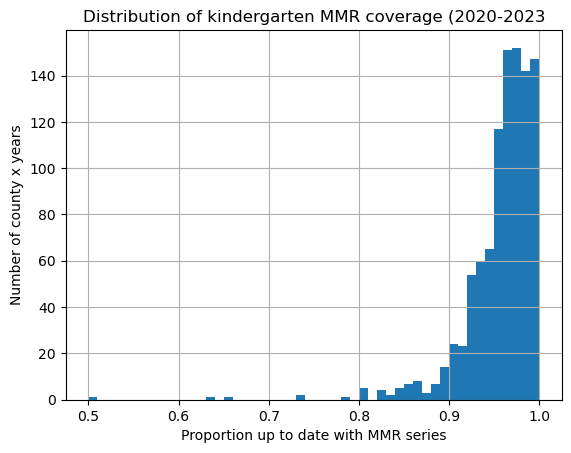

# Train Test Splits

## Random Split

Note that with this split, some counties and years  may fall entirely into either into either the test or train array by chance.

In [394]:
# perform random split
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns='kin_mmr_cov'), 
                                                    data.kin_mmr_cov, test_size=0.25, 
                                                    random_state=1)

In [395]:
print(y_train.shape, y_test.shape)
print(print(y_train.head(), y_test.head()))

(747,) (249,)
930     0.848624
302     0.964981
163     1.000000
272     0.962150
1013    0.955947
Name: kin_mmr_cov, dtype: float64 363    0.986711
617    0.975410
825    1.000000
936    0.954930
246    0.982169
Name: kin_mmr_cov, dtype: float64
None


In [396]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)



(747, 34) (249, 34)
(747,) (249,)


In [397]:
X_train.dtypes

county_name                                       object
% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
Infant Mortality Rate                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Segregation index_b                              float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                        

In [398]:
# Make sure X_train and X_test have the same columns
missing_cols = set(X_train.columns) - set(X_test.columns)
print(f"Columns in X_train but not X_test: {missing_cols}")

extra_cols = set(X_test.columns) - set(X_train.columns)
print(f"Columns in X_test but not X_train: {extra_cols}")

Columns in X_train but not X_test: set()
Columns in X_test but not X_train: set()


In [399]:
# check length and data types of y_train and y_test
print(y_train.dtypes)
print(y_test.dtypes)
print(len(y_train))
print(len(y_test))

float64
float64
747
249


In [400]:
X_test.dtypes

county_name                                       object
% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
Infant Mortality Rate                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Segregation index_b                              float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                        

In [401]:
# calculate the average MMR coverage in the test set
print("Mean MMR coverage in training data:", round(y_train.mean(),5), "\nMean MMR coverage in test data:", round(y_train.mean(),5))

Mean MMR coverage in training data: 0.95766 
Mean MMR coverage in test data: 0.95766


Check to see if any counties or year put in test or train, but not the other

In [402]:
# check for differences in counties
X_train_set = set(X_train['county_name'].unique())
X_test_set = set(X_test['county_name'].unique())
X_train_unique_cols = X_train_set-X_test_set
print(f"The training data set has {len(X_train_unique_cols)} column(s) not found in the testing data set : {X_train_unique_cols}")

X_test_unique_cols = X_test_set-X_train_set
print(f"\nThe testing data set has {len(X_test_unique_cols)} column(s) not found in the training data set : {X_test_unique_cols}")

The training data set has 82 column(s) not found in the testing data set : {'Newton', 'Hunt', 'McLennan', 'Nacogdoches', 'Deaf Smith', 'Victoria', 'Collingsworth', 'Bandera', 'Howard', 'Mills', 'Hays', 'Clay', 'Lynn', 'Matagorda', 'Van Zandt', 'Sterling', 'Goliad', 'Wheeler', 'Mitchell', 'Cameron', 'Liberty', 'Carson', 'Karnes', 'Rusk', 'Milam', 'Callahan', 'Crosby', 'Gonzales', 'Comanche', 'Motley', 'Bexar', 'Webb', 'Roberts', 'Hood', 'Winkler', 'Caldwell', 'Ellis', 'Refugio', 'Grayson', 'Travis', 'Donley', 'Comal', 'Kaufman', 'Guadalupe', 'Montgomery', 'Hardeman', 'San Augustine', 'Briscoe', 'Hansford', 'Blanco', 'Wood', 'Marion', 'Coke', 'Upton', 'Zavala', 'Collin', 'La Salle', 'Archer', 'Starr', 'Kendall', 'Kenedy', 'Leon', 'Kent', 'Burleson', 'Jim Wells', 'Ector', 'Live Oak', 'Haskell', 'Shelby', 'Menard', 'Freestone', 'Brazos', 'Walker', 'Pecos', 'Wilbarger', 'Hutchinson', 'McCulloch', 'Potter', 'Brewster', 'Kerr', 'Runnels', 'Presidio'}

The testing data set has 3 column(s) not 

In [403]:
# check for differences in years

X_train_set = set(X_train.year.unique())
X_test_set = set(X_test['year'].unique())
X_train_unique_years = X_train_set-X_test_set
print(f"\nThe training data set has {len(X_train_unique_years)} years not found in the testing data set : {X_train_unique_years}")

X_test_unique_years = X_test_set-X_train_set
print(f"\nThe testing data set has {len(X_test_unique_years)} years not found in the training data set : {X_test_unique_years}")


The training data set has 0 years not found in the testing data set : set()

The testing data set has 0 years not found in the training data set : set()


Noting that this split was done such that prediction models can be run across all years.

### Save processed Random split data

Save the split data before standardization and imputation since this will be part of my pipeline in the next script. 
However, the code was first developed and tested in this script but changes not saved.

In [404]:
# check for county_name
print(f"Check county_name is in the data set? {'county_name' in (data.columns)}")

Check county_name is in the data set? True


In [405]:
# Create new folder
new_dir = '/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/random_split/'
os.makedirs(new_dir, exist_ok=True)  # exist_ok=True won't error if it already exists
# Now change to it
os.chdir(new_dir)# save the data to a new csv files

X_train.to_csv('X_train.csv', index=False) # do not save numeric index as separate column
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

### Develop Standardize scales function

**Question:** i didn't standardize my year for interpretability. is that okay?

In [406]:
X_train.dtypes

county_name                                       object
% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
Infant Mortality Rate                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Segregation index_b                              float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                        

Split data into numeric vs. boolean features before standardization since only numeric features need to be standardized

In [407]:
X_train.columns

Index(['county_name', '% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout',
       'other_pc_provider_ratio_numerator', 'seg_missing_bool'],
      dtype='object')

In [408]:

def standardizze (df_train, df_test):
    # save original shapes
    original_train_shape = df_train.shape
    original_test_shape = df_test.shape

    print(f"***** Dataframe that will not be standardized*****\n")
    dont_std_cols = [col for col in df_train.columns if col.startswith('OH_')] + ['seg_missing_bool'] + ['year']
    print(f" Columns that wont be standardized: {dont_std_cols}")
    
    print(f"\n***** Dataframe to be standardized*****\n")
    # create subset of df with only numeric cols to be standardized
    cols_to_std = df_train.select_dtypes(include = ['int','float']).columns.to_list()
    cols_to_std = [col for col in cols_to_std if col not in dont_std_cols]

    # print(f"Dataframe has {len(cols_to_std)} numeric columns except year which are: \n{cols_to_std}\n")
    print(f"Dataframe to be standardized - shape: {df_train[cols_to_std].shape}\n")

    # create versions of each df with data that won't be standardized in scaler
    # train & test df's
    train_no_std_df = df_train[dont_std_cols]
    test_no_std_df = df_test[dont_std_cols]
    print(f"df_train of columns that will not be standardized has this shape: {train_no_std_df.shape}")
    print(f"df_test of columns that will not be standardized has this shape: {test_no_std_df.shape}\n")
    # print(f"and these data types are: \n{dont_std_cols_df.dtypes.value_counts()}")

    # scale the columns identified for standardization
    print(f"***** Scaling subsets of the data .... *****\n")
    # train scaler on X_train
    scaler = StandardScaler()
    scaler.fit(df_train[cols_to_std])
    scaled_array = scaler.transform(df_train[cols_to_std])
    df_train_std = pd.DataFrame(scaled_array, columns=cols_to_std, index=df_train.index)
    print(f"Standardized X training df has this shape: {df_train_std.shape}")

    # apply same scaler to X_test
    scaled_array2 = scaler.transform(df_test[cols_to_std])
    df_test_std = pd.DataFrame(scaled_array2, columns=cols_to_std, index=df_test.index)
    print(f"Standardized X test df has this shape: {df_test_std.shape}\n")

    # recombine unstandardized data with standardized data
    # recombine X_train
    X_train_testing = pd.concat([df_train_std, train_no_std_df], axis=1)
    X_test_testing = pd.concat([df_test_std, test_no_std_df], axis=1)

    print(f"***** Assess changes and save with select standardized columns *****\n")
    # assess work and save 
    if original_train_shape == X_train_testing.shape:
        X_train = X_train_testing # save over original if shapes match
        print(f"New version of X_train saved over the original version with standardized values") 
    else:
        print(f"Error occured. Did not save X_train_testing over X_train")
        print(f"The shape of X_train_testing is {X_train_testing.shape} but its original shape was {original_train_shape}")
        #print(f"Original df_train columns: {df_train.columns}")
        #print(f"Modified df_train columns: {X_train_testing.columns}")
        X_train_testing_set = set(X_train_testing.columns.to_list())
        X_train_original_set = set(df_train.columns.to_list())
        difference_train = X_train_testing_set-X_train_original_set
        print(f"The difference between the training data sets is the column(s) : {difference_train}")

    if original_test_shape == X_test_testing.shape:
        X_test = X_test_testing # save over original if shapes match
        print("New version of X_test saved over the original version with standardized values") 
    else:
        print(f"Error occured. Did not save X_test_testing over X_test")
        print(f"The shape of X_test_testing is {X_test_testing.shape} but its original shape was {original_test_shape}")    

The function was developed in this script but then moved to the next script.
I stopped tweaking these in this script and have tweaked in the next script instead

In [409]:
# standardizze(X_train, X_test)

### Develop custom imputer function

In [410]:
X_train.shape

(747, 34)

In [411]:
# Convert index to numeric before apply imputer fxn as it causes issues
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Confirm the indices are numeric
print(X_train.index)
print(X_test.index)
print(y_train.index)
print(y_test.index)

RangeIndex(start=0, stop=747, step=1)
RangeIndex(start=0, stop=249, step=1)
RangeIndex(start=0, stop=747, step=1)
RangeIndex(start=0, stop=249, step=1)


In [412]:
    # print variables that are missing at least one value
    X_train_missing_summary_df = pd.DataFrame({'# Missing':X_train.isnull().sum(),'% Missing': round(X_train.isnull().sum()/len(X_train),2)})
    X_train_missing_summary_df =X_train_missing_summary_df[X_train_missing_summary_df['# Missing']>0].sort_values(by = '% Missing', ascending=False)
    print(X_train_missing_summary_df)

                                   # Missing  % Missing
Infant Mortality Rate                    521       0.70
% Low Birthweight                        403       0.54
% Broadband Access                       368       0.49
% Less Than 18 Years of Age              368       0.49
Segregation index_b                      250       0.33
live_births                              202       0.27
% Female                                 184       0.25
% Rural                                  184       0.25
# Primary Care Physicians                 62       0.08
Primary Care Physicians Rate              62       0.08
Other Primary Care Provider Rate          13       0.02
other_pc_provider_ratio_numerator         13       0.02
% Vaccinated Flu                           2       0.00
kin_HepA_cov                               1       0.00
kin_HepB_cov                               1       0.00
kin_polio_cov                              1       0.00


In [413]:
def impute_please (X_train, X_test,per_change_thresh):
    '''impute based on existing values for variables where we can assume the county value will not change from year to year
        X_train - design matrix
        X_test - test design matrix
        per_change_thresh - decimal used to define 'little change' over the 4 years
        returns X_train, X_test with imputed data and no missing values'''
    # save original shapes
    original_train_shape = X_train.shape
    original_test_shape = X_test.shape
    
    # 1. Simple Imputation
    
    # print variables that are missing at least one value
    X_train_missing_summary_df = pd.DataFrame({'# Missing':X_train.isnull().sum(),'% Missing': round(X_train.isnull().sum()/len(X_train),2)})
    X_train_missing_summary_df =X_train_missing_summary_df[X_train_missing_summary_df['# Missing']>(per_change_thresh*100)].sort_values(by = '% Missing', ascending=False)
    # print(X_train_missing_summary_df)
    cols_missing_data = X_train_missing_summary_df.index.to_list()

    # identify first group of variables for imputation based on the fact that they are fairly constant over the 4 years
    cols_missing_data_plus_year = cols_missing_data +['year']
    print(type(X_train[cols_missing_data_plus_year]))

    means_by_year = X_train[cols_missing_data_plus_year].groupby('year').mean()    
    cols_little_changes = [
        col for col in X_train[cols_missing_data_plus_year].columns 
        if col != 'year' and 
        abs((means_by_year.loc[2023, col] - means_by_year.loc[2020, col]) / means_by_year.loc[2020, col]) * 100 < (per_change_thresh*100)
    ]
    print(f"Imputing values for columns with <{per_change_thresh*100}% change.....\nThese columns are: {cols_little_changes}")
    
    # replace variables that are fairly constant with their median value across all counties/years
    imputer = SimpleImputer(strategy = 'median', add_indicator = False)

    for col in cols_little_changes:
        # fit on training data
        imputer.fit(X_train[[col]])
        x = imputer.transform(X_train[[col]])
        y = imputer.transform(X_test[[col]])

        # Impute Training & test data
        # convert resulting array to df
        imputed_train_col_df = pd.DataFrame(x, columns = [col], index= X_train.index)
        imputed_test_col_df = pd.DataFrame(y, columns = [col], index= X_test.index)

        print("Check results for training data set:")
        print(f"Original df missing count for this column: {X_train[col].isna().sum()}")
        print(f"Modified df missing count for this column: {imputed_train_col_df[col].isna().sum()}")

        print(f"Shape of original column: {X_train[col].shape}")
        print(f"Shape of modified column: {imputed_train_col_df[col].shape}")
        
        X_train_testing = X_train.copy()
        X_train_testing[col] = imputed_train_col_df[col] # save imputed data over original
        
        if X_train_testing.shape == X_train.shape:
            X_train = X_train_testing # save newly imputed values for that column
            print(f"Imputed values saved for {col}\n")
        else: 
            print(f"Error occured. Did not save modified df X_train_testing over X_train")
            print(f"Original X_train df shape: {X_train.shape}")
            print(f"Modified X_train df shape: {X_train_testing.shape}")  

        print("Check results for testing data set:")
        print(f"Original df missing count for this column: {X_test[col].isna().sum()}")
        print(f"Modified df missing count for this column: {imputed_test_col_df[col].isna().sum()}")

        print(f"Shape of original column: {X_test[col].shape}")
        print(f"Shape of modified column: {imputed_test_col_df[col].shape}")
        
        X_test_testing = X_test.copy()
        X_test_testing[col] = imputed_test_col_df[col] # save imputed data over original
        
        if X_test_testing.shape == X_test.shape:
            X_test = X_test_testing # save newly imputed values for that column
            print(f"Imputed values saved for {col}\n")
        else: 
            print(f"Error occured. Did not save modified df X_test_testing over X_train")
            print(f"Original X_test df shape: {X_test.shape}")
            print(f"Modified X_test df shape: {X_test_testing.shape}")  
            
    print("Final results of simple imputation with median for select features:")
    print("Training df:")
    print(X_train[cols_little_changes].isna().sum().sort_values(ascending = False)) 
    print("\nTesting df:")
    print(X_test[cols_little_changes].isna().sum().sort_values(ascending = False))      

    
    # 2. Interpolate remaining variables


    # identify 2nd group of variables for imputation that vary over the defined threshold
#    means_by_year = X_train[cols_missing_data_plus_year].groupby('year').mean()    
#    cols_larger_changes = [
#        col for col in X_train[cols_missing_data_plus_year].columns 
#        if col != 'year' and 
#        abs((means_by_year.loc[2023, col] - means_by_year.loc[2020, col]) / means_by_year.loc[2020, col]) * 100 >= (per_change_thresh*100)
#    ]
#    print(f"\nImputing values for {len(cols_larger_changes)} columns with =>{per_change_thresh*100}% change.....\nThese columns are: {cols_larger_changes}")


    # identify remaining columns to impute
    difference = set(X_train.columns) - set(cols_little_changes)
    # Always include 'year' (adding to a set is idempotent - no duplicates)
    difference.add('year')
    # Convert to list if needed
    remaining_cols_to_impute = list(difference)
    print(f"\nImputing values for {len(remaining_cols_to_impute)} columns with missing values....\nThese columns are: {remaining_cols_to_impute}")
    
    # Apply linear interpolation
    # Training data
    # sort rows by county and year to interpolate each missing value according to its county
    X_train = X_train.sort_values(by = ['county_name','year'])
    # apply interpolate command to one county at a time with year values in different rows
    X_train[remaining_cols_to_impute] = (
        X_train.groupby('county_name')[remaining_cols_to_impute]
            .transform(lambda x: x.interpolate(method='linear').ffill().bfill())
    )
    print("\nFinal results of interpolation on:")
    print("Training df:")
    print(X_train[remaining_cols_to_impute].isna().sum())

    # Apply linear interpolation
    # Testing data
    print("Testing df:")
    X_test = X_test.sort_values(by = ['county_name','year'])
    # apply interpolate command to one county at a time with year values in different rows
    X_test[remaining_cols_to_impute] = (
        X_test.groupby('county_name')[remaining_cols_to_impute]
            .transform(lambda x: x.interpolate(method='linear').ffill().bfill())
    )
    print(X_test[remaining_cols_to_impute].isna().sum())

    
    # 3. Impute the remaining missing values globally (regardless of year or county) 
    # global imputation

    for var in remaining_cols_to_impute:
        # Calculate median from TRAINING data only
        train_median = X_train[var].median()
        
        # Apply to both train and test
        X_train[var].fillna(train_median, inplace=True)
        X_test[var].fillna(train_median, inplace=True) 

    print("\nFinal results after global imputation:")
    print("Training df:")
    print(X_train[remaining_cols_to_impute].isna().sum())
    print("\nTest df:")
    print(X_test[remaining_cols_to_impute].isna().sum())


    print(f"***** Check and save with select standardized columns *****\n")
    # assess work and save 
    print(f"The shape of X_train is {X_train.shape}; its original shape was {original_train_shape}")
    print(f"The shape of X_test is {X_test.shape}; its original shape was {original_test_shape}")
    print(f"The final number of missing values in X_train is {X_train.isna().sum()}")
    print(f"The final number of missing values in X_test is {X_test.isna().sum()}")
    
    return X_train, X_test


The function was developed in this script but then moved to the next script.
I stopped tweaking these in this script and have tweaked in the next script instead

In [414]:
# X_train, X_test = impute_please(X_train,X_test,0.03)

In [415]:
print(X_train.shape)
print(X_test.shape)

(747, 34)
(249, 34)


In [416]:
print(X_train.isna().sum())
print("\n", X_train.isna().sum())

county_name                                        0
% Low Birthweight                                403
# Primary Care Physicians                         62
Primary Care Physicians Rate                      62
% Vaccinated Flu                                   2
% Children in Poverty                              0
Infant Mortality Rate                            521
# Uninsured Children                               0
% Uninsured Children                               0
# Food Insecure                                    0
% Food Insecure                                    0
Segregation index_b                              250
Other Primary Care Provider Rate                  13
Median Household Income                            0
% Enrolled in Free or Reduced Lunch                0
Population                                         0
% Female                                         184
% Rural                                          184
year                                          

### Run check to make sure data is model-ready

In [417]:
print(type(X_test), type(y_train), type(X_test), type(y_test))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'> <class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


In [418]:
# convert booleans to numeric
dfs = [X_train,X_test]
for df in dfs:
    bool_list = df.select_dtypes(include = ['bool']).columns.to_list() # can only select_dtypes from dfs
    df[bool_list] = df[bool_list].astype('int')

In [419]:
# final check for missing values
pd.DataFrame({"X_train missing":X_train.isnull().sum().sort_values(ascending = False),
              "X_test missing":X_test.isnull().sum().sort_values(ascending = False)}
              )

,X_train missing,X_test missing
# Food Insecure,0,0
# Primary Care Physicians,62,19
# Uninsured Children,0,0
% Broadband Access,368,131
% Children in Poverty,0,0
% Enrolled in Free or Reduced Lunch,0,0
% Female,184,64
% Food Insecure,0,0
% Less Than 18 Years of Age,368,131
% Low Birthweight,403,127


Check data types

In [420]:
X_train.dtypes

county_name                                       object
% Low Birthweight                                float64
# Primary Care Physicians                        float64
Primary Care Physicians Rate                     float64
% Vaccinated Flu                                 float64
% Children in Poverty                            float64
Infant Mortality Rate                            float64
# Uninsured Children                               int64
% Uninsured Children                             float64
# Food Insecure                                    int64
% Food Insecure                                  float64
Segregation index_b                              float64
Other Primary Care Provider Rate                 float64
Median Household Income                            int64
% Enrolled in Free or Reduced Lunch              float64
Population                                         int64
% Female                                         float64
% Rural                        

In [421]:
print(X_train.index)
print(X_test.index)
print(y_train.index)
print(y_test.index)

RangeIndex(start=0, stop=747, step=1)
RangeIndex(start=0, stop=249, step=1)
RangeIndex(start=0, stop=747, step=1)
RangeIndex(start=0, stop=249, step=1)


In [422]:
# Find which column is missing from X_test
missing_cols = set(X_train.columns) - set(X_test.columns)
print(f"Columns in X_train but not X_test: {missing_cols}")

extra_cols = set(X_test.columns) - set(X_train.columns)
print(f"Columns in X_test but not X_train: {extra_cols}")

Columns in X_train but not X_test: set()
Columns in X_test but not X_train: set()


## Group Split

If goal is understanding predictors of MMR coverage, group split will make sure a given county is only in train or test array.
This is helpful in ensuring model isn't just learning that a certain county has high or low values which would artificially increase its accuracy on test data. This way it's seeing completely new counties in the test data and has to base its predictions on the features in X_test.

Using **GroupKFold**, which creates a complete partition of the data into k folds. Each unique group is assigned to exactly one fold, and each sample is used in the test set exactly once across all iterations.By default, it is not randomized and does not have a shuffle or random_state parameter, providing a reproducible set of splits. This seemed a better approach than GroupShuffleSplit in which a sample may be tested multiple or zero times and samples could occur in more than one fold.

In [423]:
# check for county_name
print(f"Check county_name is in the data set? {'county_name' in (data.columns)}")

# create X and y
X = data.drop(columns='kin_mmr_cov')
y = data['kin_mmr_cov']

# use GroupKFold
gkf = GroupKFold(n_splits=5) 
group = X.index 
for train_idx, test_idx in gkf.split(X, y, groups=group):
    # Use the indices to slice your data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

Check county_name is in the data set? True


In [424]:
print(f"X_test shape: {X_test.shape},\ny_train shape: {(y_train.shape)},\n X_test shape:{ X_test.shape},\n y_test shape:{(y_test.shape)}")

X_test shape: (199, 34),
y_train shape: (797,),
 X_test shape:(199, 34),
 y_test shape:(199,)


In [425]:
# check for differences in counties

X_train_set = set(X_train.index.unique().to_list())
X_test_set = set(X_test.index.unique().to_list())
X_train_unique_cols = X_train_set-X_test_set
print(f"The training data set has {len(X_train_unique_cols)} column(s) not found in the testing data set")# : {X_train_unique_cols}")

X_test_unique_cols = X_test_set-X_train_set
print(f"\nThe testing data set has {len(X_test_unique_cols)} column(s) not found in the training data set")# : {X_test_unique_cols}")

The training data set has 797 column(s) not found in the testing data set

The testing data set has 199 column(s) not found in the training data set


In [426]:
# check for differences in years

X_train_set = set(X_train.year.unique())
X_test_set = set(X_test['year'].unique())
X_train_unique_years = X_train_set-X_test_set
print(f"\nThe training data set has {len(X_train_unique_years)} years not found in the testing data set : {X_train_unique_years}")

X_test_unique_years = X_test_set-X_train_set
print(f"\nThe testing data set has {len(X_test_unique_years)} years not found in the training data set : {X_test_unique_years}")


The training data set has 0 years not found in the testing data set : set()

The testing data set has 0 years not found in the training data set : set()


In [427]:
print(f"Check county_name is in the data set? {'county_name' in (data.columns)}")

Check county_name is in the data set? True


### Save Group split data

In [428]:
# Create new folder
new_dir = '/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/group_split/'
os.makedirs(new_dir, exist_ok=True)  # exist_ok=True won't error if it already exists
# Now change to it
os.chdir(new_dir)# save the data to new subfolder

# save the data to a new csv files
X_train.to_csv('X_train.csv', index=False) # do not save numeric index as separate column
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

## Temporal Split

Train on years 1-3, Test on year 4. This tests if your model can predict the future.

Downside is that model may just memorize mean for a given county and apply that for 2023 without necessarily learning how predictors influence the mean for a given coverage.

In [275]:
stop

NameError: name 'stop' is not defined

In [429]:
# check for county_name
print(f"Check county_name is in the data set? {'county_name' in (data.columns)}")

Check county_name is in the data set? True


In [430]:
data = data.sort_values(by= 'year')
data_t1 = data[data['year']<2023]
data_t2 = data[data['year']==2023]
print(f"Shape of df for years 2020-2022:{data_t1.shape}")
print(f"Shape of df for year 2023:{data_t2.shape}")


Shape of df for years 2020-2022:(747, 35)
Shape of df for years 2023:(249, 35)


In [431]:
# random train_test_split and create split manually
X1_train = data_t1.drop(columns='kin_mmr_cov')
X2_test = data_t2.drop(columns='kin_mmr_cov')
y1_train = data_t1['kin_mmr_cov']
y2_test = data_t2['kin_mmr_cov']


In [433]:
print(f"X1_train shape: {X1_train.shape},\n X2_test shape: {X2_test.shape},\ny1_train shape: {(y1_train.shape)},\n y2_test shape:{ y2_test.shape}")

X1_train shape: (747, 34),
 X2_test shape: (249, 34),
y1_train shape: (747,),
 y2_test shape:(249,)


### Save Temporal split data

In [434]:
# Create new folder
new_dir = '/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/temporal_split/'
os.makedirs(new_dir, exist_ok=True)  # exist_ok=True won't error if it already exists
# Now change to it
os.chdir(new_dir)# save the data to new subfolder

# save the data to a new csv file
X1_train.to_csv('X1_train.csv', index=False) # do not save numeric index as separate column
X2_test.to_csv('X2_test.csv', index=False)
y1_train.to_csv('y1_train.csv', index=False)
y2_test.to_csv('y2_test.csv', index=False)


In [435]:
print(f"Check county_name is in the data set? {'county_name' in (X1_train.columns)}")

Check county_name is in the data set? True


In [438]:
X1_train.isna().sum().sort_values(ascending = False)

Infant Mortality Rate                            520
% Low Birthweight                                513
% Less Than 18 Years of Age                      250
% Broadband Access                               250
% Rural                                          248
% Female                                         248
Segregation index_b                              247
Primary Care Physicians Rate                      60
# Primary Care Physicians                         60
live_births                                       21
Other Primary Care Provider Rate                  14
other_pc_provider_ratio_numerator                 14
% Vaccinated Flu                                   3
kin_HepA_cov                                       1
kin_polio_cov                                      1
kin_HepB_cov                                       1
CVAC level of concern for vaccination rollout      0
Social Vulnerability Index (SVI)                   0
Estimated strongly hesitant                   

next steps: build pipeline to test various models

In [ ]:
## Annual split